Loading Reuters Data...
2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data Loaded. Training Shape: (8982, 150)
Number of Topics: 46

Training Baseline Model...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.3318 - loss: 2.7019 - val_accuracy: 0.4674 - val_loss: 2.2437
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.4772 - loss: 2.1450 - val_accuracy: 0.5003 - val_loss: 2.0694
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.4909 - loss: 2.0587 - val_accuracy: 0.3461 - val_loss: 2.1722
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.4907 - loss: 1.9670 - val_accuracy: 0.4958 - val_loss: 2.0002
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.5166 - loss: 1.8364 - val_accuracy: 0.4747 - val_loss: 2.0776
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.5404 - loss: 1.7462 - val_accuracy: 0.5042 - val_loss: 1.8382
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.5802 - loss: 1.6151 - val_accuracy: 0.5782 - val_loss: 1.6360
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.6117 - loss: 1.5165 - val_accuracy: 0.

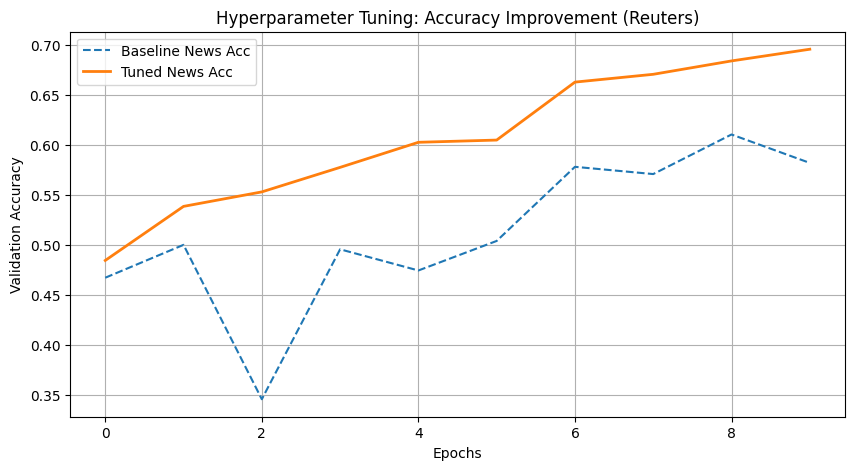

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PREPROCESSING ---
# Only keep the top 10,000 most frequently occurring words
MAX_WORDS = 10000
# Cut off news articles after 150 words
MAX_LEN = 150

print("Loading Reuters Data...")
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=MAX_WORDS)

# Pad sequences (ensure all inputs are same length)
X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

print(f"Data Loaded. Training Shape: {X_train.shape}")
print(f"Number of Topics: {len(np.unique(y_train))}")

# --- 2. BASELINE MODEL (Simple LSTM) ---
def build_baseline_model():
    model = Sequential()
    model.add(Embedding(input_dim=MAX_WORDS, output_dim=32, input_length=MAX_LEN))
    model.add(LSTM(32)) # Simple LSTM
    # 46 units for 46 topics, 'softmax' for multi-class
    model.add(Dense(46, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

print("\nTraining Baseline Model...")
baseline = build_baseline_model()
hist_base = baseline.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2, verbose=1)

# --- 3. TUNED MODEL (Hyperparameter Optimization) ---
# Improvements:
# 1. Output Dim: Increased Embedding size to 128 for news nuances.
# 2. Dropout: Added SpatialDropout to prevent overfitting to specific news keywords.
# 3. Units: Increased LSTM units to 128 for multi-topic complexity.
def build_tuned_model():
    model = Sequential()
    model.add(Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN))
    model.add(SpatialDropout1D(0.3))
    model.add(LSTM(128, dropout=0.2)) # Robust LSTM
    model.add(Dense(46, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

print("\nTraining Tuned Model...")
tuned = build_tuned_model()
hist_tuned = tuned.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2, verbose=1)

# --- 4. COMPARISON & RESULTS ---
score_base = baseline.evaluate(X_test, y_test, verbose=0)
score_tuned = tuned.evaluate(X_test, y_test, verbose=0)

print("-" * 40)
print(f"Baseline News Accuracy: {score_base[1]*100:.2f}%")
print(f"Tuned News Accuracy:    {score_tuned[1]*100:.2f}%")
print("-" * 40)

# Plotting Improvement
plt.figure(figsize=(10, 5))
plt.plot(hist_base.history['val_accuracy'], label='Baseline News Acc', linestyle='--')
plt.plot(hist_tuned.history['val_accuracy'], label='Tuned News Acc', linewidth=2)
plt.title('Hyperparameter Tuning: Accuracy Improvement (Reuters)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()